Adaboost Regression


1. Load the concrete compressive strength dataset from UCI:  
https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength. Check the dataset to remove duplicate entries and handle missing feature values (through imputation or removal depending on the number of samples having missing feature values). Split the dataset into training, validation and test sets (70%-15%-15%). 

In [15]:
# Import pandas library for data manipulation and analysis
import pandas as pd
# Import numpy library for numerical operations
import numpy as np
# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt
# Import seaborn for statistical data visualization
import seaborn as sns
# Import train_test_split function to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import StandardScaler for normalizing features
from sklearn.preprocessing import StandardScaler

# Load the dataset
# Define the URL where the concrete dataset is stored online
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
# Read the Excel file from the URL and store it in a DataFrame
df = pd.read_excel(url)

# Print the dimensions of the dataset (rows and columns)
print(f"Dataset shape: {df.shape}")
# Print the names of all columns in the dataset
print(f"Columns: {list(df.columns)}")

# Display basic info about the dataset
# Print a newline and header for dataset information
print("\nDataset Info:")
# Display detailed information about the dataset including data types and memory usage
print(df.info())

# Print a newline and header for first few rows
print("\nFirst 5 rows:")
# Display the first 5 rows of the dataset
print(df.head())

# Print a newline and header for statistical summary
print("\nDataset Statistics:")
# Display statistical summary including mean, std, min, max for each column
print(df.describe())

# Check for missing values and duplicates
# Count and display missing values in each column
print("Missing values per column:\n", df.isnull().sum())
# Count and display the number of duplicate rows in the dataset
print("Number of duplicate rows:", df.duplicated().sum())

# Handle missing and duplicate values
# Remove duplicate rows from the dataset
df = df.drop_duplicates()
# Fill any missing values with the median value of each column
df = df.fillna(df.median())  # this dataset has none
# Print confirmation message that duplicates were removed
print("duplicate removed")
# Verify that no duplicate rows remain after removal
print("Number of duplicate rows:", df.duplicated().sum())

# Split features and target
# Extract all columns except the last one as input features (X)
X = df.iloc[:, :-1]
# Extract the last column as the target variable (y)
y = df.iloc[:, -1]

# Split data into 70% training and 30% temporary (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
# Split the temporary data equally into validation and test sets (15% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the shapes of training, validation, and test sets
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Dataset shape: (1030, 9)
Columns: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3


2. Implement an Adaboost regressor (Adaboost.R2 algorithm from scratch as follows):  <br>
      a. Use decision tree stumps as individual regressors (students are permitted to use DecisionTreeRegressor from scikit-learn with max_depth=1, i.e. they need not implement the decision tree regressor from scratch).

      b. Implement the Steps 1-3 of the Adaboost.R2 algorithm for regression as given in the attached pdf.


In [16]:
# Import numpy library for numerical operations
import numpy as np
# Import DecisionTreeRegressor for creating weak learners
from sklearn.tree import DecisionTreeRegressor
# Import evaluation metrics for model performance
from sklearn.metrics import r2_score, mean_squared_error

# Define the adaBoostR2 class for regression boosting
class adaBoostR2:
    # Initialize the AdaBoostR2 model with default parameters
    def __init__(self, nEstimators=50, randomState=None):
        # Set the number of boosting iterations
        self.nEstimators = nEstimators
        # Set random seed for reproducibility
        self.randomState = randomState
        # Store list of trained weak learners
        self.weakLearners = []
        # Store alpha weights for each weak learner
        self.alphaWeights = []
        # Store training errors for each iteration
        self.trainingErrors = []

    # Train the AdaBoostR2 model on training data
    def fit(self, X, y):
        # Convert input features to numpy array
        X = np.array(X)
        # Convert target values to numpy array
        y = np.array(y)
        # Get the number of training samples
        nSamples = X.shape[0]

        # Print training start information
        print(f"Starting AdaBoost.R2 training with {self.nEstimators} estimators...")
        # Print dataset information
        print(f"Training on {nSamples} samples with {X.shape[1]} features")

        # Step 1: Initialize weights
        # Assign equal weights to all samples: w_i^(1) = 1/N
        weights = np.ones(nSamples) / nSamples
        # Print weight initialization information
        print(f"Step 1: Initialized weights - all samples have weight = {1/nSamples:.6f}")

        # Step 2: For each boosting round m = 1, 2, ..., M
        # Loop through each boosting iteration
        for m in range(self.nEstimators):
            # Show progress every 10 iterations
            if m % 10 == 0:  # Progress indicator
                # Print current iteration progress
                print(f"Training weak learner {m+1}/{self.nEstimators}...")

            # 2a. Train weak learner h_m(x) on the weighted dataset
            # Using DecisionTreeRegressor with max_depth=1
            # Create a decision tree with depth 1
            weakLearner = DecisionTreeRegressor(
                # Limit tree depth to 1 for weak learning
                max_depth=1,
                # Set random state for reproducibility
                random_state=self.randomState
            )

            # Train on weighted dataset (sklearn handles sample weights)
            weakLearner.fit(X, y, sample_weight=weights)

            # 2b. Compute absolute errors: e_i = |y_i - h_m(x_i)|
            predictions = weakLearner.predict(X)
            # Calculate absolute errors between true and predicted values
            absoluteErrors = np.abs(y - predictions)

            # 2c. Normalize errors to [0, 1]: L(y_i, h_m(x_i)) = e_i / max_j(e_j)
            maxError = np.max(absoluteErrors)
            # Handle case where all predictions are perfect
            if maxError == 0:  # Handle edge case where all predictions are perfect
                # Set normalized errors to zero if max error is zero
                normalizedErrors = np.zeros_like(absoluteErrors)
            else:
                # Normalize errors by dividing by maximum error
                normalizedErrors = absoluteErrors / maxError

            # 2d. Compute weighted error: e_m = sum(w_i * L_i) / sum(w_i)
            weightedError = np.sum(weights * normalizedErrors) / np.sum(weights)

            # 2e. Compute model weight: beta_m = e_m / (1 - e_m)
            # Stopping condition: if e_m >= 0.5, stop boosting
            if weightedError >= 0.5:
                # Print early stopping message
                print(f"Stopping early at iteration {m+1}: weighted error {weightedError:.4f} >= 0.5")
                # Exit the boosting loop
                break

            # Calculate beta weight for this weak learner
            betaM = weightedError / (1 - weightedError)

            # 2f. Update sample weights: w_i^(m+1) = w_i^(m) * beta_m^(1 - L_i)
            # Update sample weights based on prediction errors
            weights = weights * (betaM ** (1 - normalizedErrors))

            # 2g. Normalize weights: w_i^(m+1) = w_i^(m+1) / sum(w_j^(m+1))
            # Normalize weights to sum to 1
            weights = weights / np.sum(weights)

            # Add trained weak learner to the list
            self.weakLearners.append(weakLearner)
            # Step 3: alpha_m = log(1/beta_m)
            # Calculate alpha weight for this weak learner
            alphaM = np.log(1 / betaM)
            # Store alpha weight
            self.alphaWeights.append(alphaM)
            # Store training error for this iteration
            self.trainingErrors.append(weightedError)

            # Print progress information every 10 iterations
            if m % 10 == 0:
                # Print current iteration statistics
                print(f"Weighted error: {weightedError:.4f}, Beta: {betaM:.4f}, Alpha: {alphaM:.4f}")

        # Print training completion information
        print(f"Training completed, Successfully trained {len(self.weakLearners)} weak learners")
        # Print final training error
        print(f"Final training error: {self.trainingErrors[-1]:.4f}")

        # Return self for method chaining
        return self

    # Make predictions on new data
    def predict(self, X):
        # Convert input to numpy array
        X = np.array(X)
        # Get number of samples to predict
        nSamples = X.shape[0]

        # Initialize predictions
        # Create array of zeros for predictions
        predictions = np.zeros(nSamples)

        # Step 3: Final Prediction
        # H(x) = sum(alpha_m * h_m(x)) / sum(alpha_m)
        # Calculate total alpha weight for normalization
        totalAlpha = np.sum(self.alphaWeights)

        # Loop through each weak learner and its weight
        for weakLearner, alphaM in zip(self.weakLearners, self.alphaWeights):
            # Get predictions from weak learner
            weakPredictions = weakLearner.predict(X)
            # Add weighted predictions to total
            predictions += alphaM * weakPredictions

        # Divide by total alpha to get final predictions
        predictions = predictions / totalAlpha

        # Return final predictions
        return predictions

    # Calculate feature importance across all weak learners
    def get_feature_importance(self):
        # Check if any weak learners exist
        if not self.weakLearners:
            # Return None if no learners trained
            return None

        # Initialize importance array with zeros
        importance = np.zeros(self.weakLearners[0].n_features_in_)

        # Loop through each weak learner and its weight
        for weakLearner, alphaM in zip(self.weakLearners, self.alphaWeights):
            # Add weighted feature importance
            importance += alphaM * weakLearner.feature_importances_

        # Normalize by total alpha weights
        totalAlpha = np.sum(self.alphaWeights)
        # Normalize importance by total alpha
        importance = importance / totalAlpha

        # Return normalized feature importance
        return importance

# Train and Evaluate
# Create adaBoostR2 model with 50 estimators and random seed 42
model = adaBoostR2(nEstimators=50, randomState=42)
# Train the model on training data
model.fit(X_train, y_train)

# Make predictions on test data
yPred = model.predict(X_test)
# Calculate R-squared score
r2 = r2_score(y_test, yPred)
# Calculate root mean squared error
rmse = mean_squared_error(y_test, yPred)

# Print R-squared score rounded to 4 decimal places
print("R² Score:", round(r2, 4))
# Print RMSE rounded to 4 decimal places
print("RMSE:", round(rmse, 4))

Starting AdaBoost.R2 training with 50 estimators...
Training on 703 samples with 8 features
Step 1: Initialized weights - all samples have weight = 0.001422
Training weak learner 1/50...
Weighted error: 0.2754, Beta: 0.3800, Alpha: 0.9675
Training weak learner 11/50...
Weighted error: 0.3958, Beta: 0.6551, Alpha: 0.4230
Training weak learner 21/50...
Weighted error: 0.4199, Beta: 0.7238, Alpha: 0.3232
Training weak learner 31/50...
Weighted error: 0.4516, Beta: 0.8235, Alpha: 0.1942
Training weak learner 41/50...
Weighted error: 0.4644, Beta: 0.8672, Alpha: 0.1424
Training completed, Successfully trained 50 weak learners
Final training error: 0.3846
R² Score: 0.4453
RMSE: 139.3336


3. Plot the R^2 score on the validation set for different values of the number of weak learners (M in the given algorithm). Accordingly, choose a suitable value of M. M = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000].

Starting AdaBoost.R2 training with 5 estimators...
Training on 703 samples with 8 features
Step 1: Initialized weights - all samples have weight = 0.001422
Training weak learner 1/5...
Weighted error: 0.2754, Beta: 0.3800, Alpha: 0.9675
Training completed, Successfully trained 5 weak learners
Final training error: 0.3838
M=    5 → Validation R² = 0.3855
Starting AdaBoost.R2 training with 10 estimators...
Training on 703 samples with 8 features
Step 1: Initialized weights - all samples have weight = 0.001422
Training weak learner 1/10...
Weighted error: 0.2754, Beta: 0.3800, Alpha: 0.9675
Training completed, Successfully trained 10 weak learners
Final training error: 0.4130
M=   10 → Validation R² = 0.4317
Starting AdaBoost.R2 training with 20 estimators...
Training on 703 samples with 8 features
Step 1: Initialized weights - all samples have weight = 0.001422
Training weak learner 1/20...
Weighted error: 0.2754, Beta: 0.3800, Alpha: 0.9675
Training weak learner 11/20...
Weighted error:

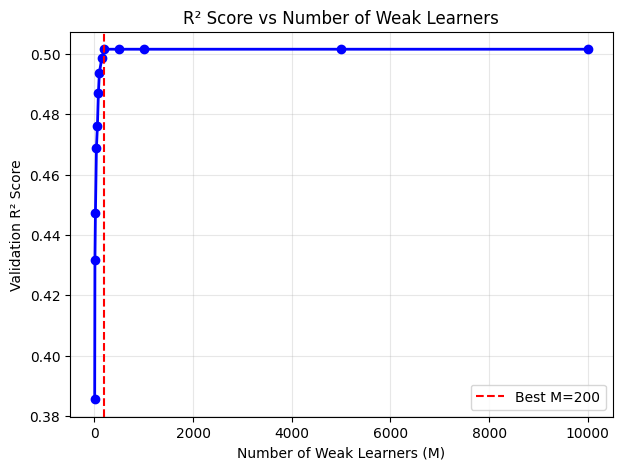

In [17]:
# Import NumPy library for numerical operations and array handling
import numpy as np

# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt

# Import evaluation metrics from scikit-learn
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Define list of different numbers of estimators to test
M_values = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000]

# Initialize empty list to store R² scores for each M value
r2_scores = []

# Loop through each value of M (number of estimators)
for M in M_values:
    # Create AdaBoost regressor with M estimators and fixed random seed
    model = adaBoostR2(nEstimators=M, randomState=42)

    # Train the model using training data
    model.fit(X_train, y_train)

    # Make predictions on validation data
    y_val_pred = model.predict(X_val)

    # Calculate R² score between actual and predicted validation values
    r2 = r2_score(y_val, y_val_pred)

    # Add the R² score to the list
    r2_scores.append(r2)

    # Print the current M value and its corresponding R² score
    print(f"M={M:5d} → Validation R² = {r2:.4f}")

# Find the index of the highest R² score
best_idx = np.argmax(r2_scores)

# Get the M value that corresponds to the best R² score
best_M = M_values[best_idx]

# Print the best M value and its R² score
print(f"\nBest M value: {best_M} with Validation R² = {r2_scores[best_idx]:.4f}")

# Create a new figure with specified width and height
plt.figure(figsize=(7,5))

# Plot M values vs R² scores with blue circles connected by lines
plt.plot(M_values, r2_scores, 'bo-', linewidth=2, markersize=6)

# Add vertical line at the best M value
plt.axvline(x=best_M, color='red', linestyle='--', label=f'Best M={best_M}')

# Set label for x-axis
plt.xlabel('Number of Weak Learners (M)')

# Set label for y-axis
plt.ylabel('Validation R² Score')

# Set title for the plot
plt.title('R² Score vs Number of Weak Learners')

# Add grid lines with transparency
plt.grid(True, alpha=0.3)

# Display the legend
plt.legend()

# Display the plot
plt.show()

4. For the Adaboost.R2 algorithm designed with the best value of M that you selected in part 3, perform prediction on the test set. Report the R^2 score on the test set and show a scatter plot of the predictions vs. The ground truths. 

Starting AdaBoost.R2 training with 200 estimators...
Training on 703 samples with 8 features
Step 1: Initialized weights - all samples have weight = 0.001422
Training weak learner 1/200...
Weighted error: 0.2754, Beta: 0.3800, Alpha: 0.9675
Training weak learner 11/200...
Weighted error: 0.3958, Beta: 0.6551, Alpha: 0.4230
Training weak learner 21/200...
Weighted error: 0.4199, Beta: 0.7238, Alpha: 0.3232
Training weak learner 31/200...
Weighted error: 0.4516, Beta: 0.8235, Alpha: 0.1942
Training weak learner 41/200...
Weighted error: 0.4644, Beta: 0.8672, Alpha: 0.1424
Training weak learner 51/200...
Weighted error: 0.3982, Beta: 0.6617, Alpha: 0.4129
Training weak learner 61/200...
Weighted error: 0.4566, Beta: 0.8402, Alpha: 0.1741
Training weak learner 71/200...
Weighted error: 0.3736, Beta: 0.5965, Alpha: 0.5166
Training weak learner 81/200...
Weighted error: 0.4834, Beta: 0.9359, Alpha: 0.0662
Training weak learner 91/200...
Weighted error: 0.4866, Beta: 0.9478, Alpha: 0.0536
Tra

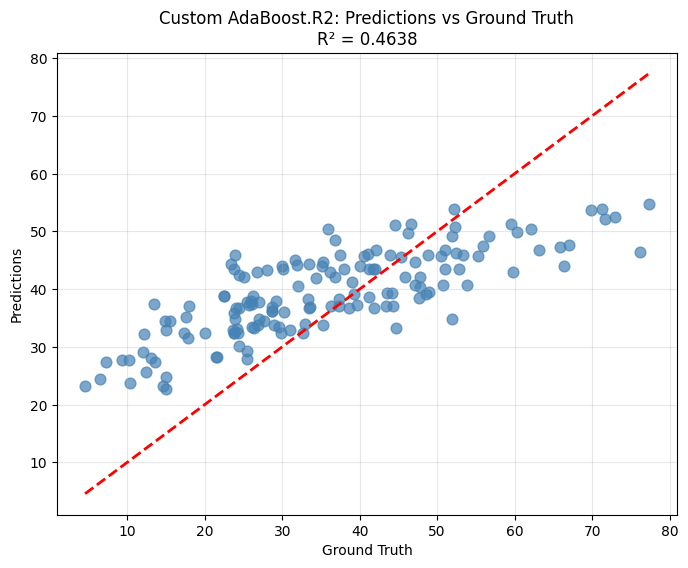

In [18]:
# Test set evaluation with custom AdaBoost.R2 (M=200)
finalModel = adaBoostR2(nEstimators=200, randomState=42)
# Train the model using the training data
finalModel.fit(X_train, y_train)

# Make predictions and calculate R²
y_testPredCustom = finalModel.predict(X_test)
# Calculate how well the predictions match the actual values
r2_custom = r2_score(y_test, y_testPredCustom)

# Display the performance score to the user
print(f"Test Set R² Score: {r2_custom:.4f}")

# Create scatter plot
# Set up a new figure with specific width and height
plt.figure(figsize=(8, 6))
# Draw points showing actual vs predicted values
plt.scatter(y_test, y_testPredCustom, alpha=0.7, s=60, color='steelblue')
# Draw a diagonal line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
# Label the x-axis
plt.xlabel('Ground Truth')
# Label the y-axis
plt.ylabel('Predictions')
# Add a title with the performance score
plt.title(f'Custom AdaBoost.R2: Predictions vs Ground Truth\nR² = {r2_custom:.4f}')
# Add a subtle grid to help read the plot
plt.grid(True, alpha=0.3)
# Display the plot on screen
plt.show()

5. Use scikit-learn's AdaboostRegressor to fit the training set by choosing  suitable values of the hyperparameters.

In [19]:
# Import the AdaBoost regressor from scikit-learn ensemble module
from sklearn.ensemble import AdaBoostRegressor
# Import decision tree regressor to use as base estimator
from sklearn.tree import DecisionTreeRegressor


# Create and train model
sklearn_adaboost = AdaBoostRegressor(
    # Use decision tree with max depth of 1 as the base estimator
    estimator=DecisionTreeRegressor(max_depth=1),
    # Set number of boosting iterations to 200
    n_estimators=200,
    # Set learning rate to 1.0 (no shrinkage)
    learning_rate=1.0,
    # Use linear loss function for regression
    loss='linear',
    # Set random state for reproducibility
    random_state=42
)

# Train the AdaBoost model on training data
sklearn_adaboost.fit(X_train, y_train)
# Print message indicating training is finished
print("Training completed!")
# Calculate R-squared score on validation predictions
y_val_pred = sklearn_adaboost.predict(X_val)
r2_val = r2_score(y_val, y_val_pred)
# Print the validation R-squared score with 4 decimal places
print(f"Validation R² Score: {r2_val:.4f}")

Training completed!
Validation R² Score: 0.5298


6. Perform prediction on the test set using scikit-learn's AdaboostRegressor trained as in part 5. Report the R^2 score and show the scatter plot of the predictions vs. Ground truths. 

Test Set R² Score: 0.4519


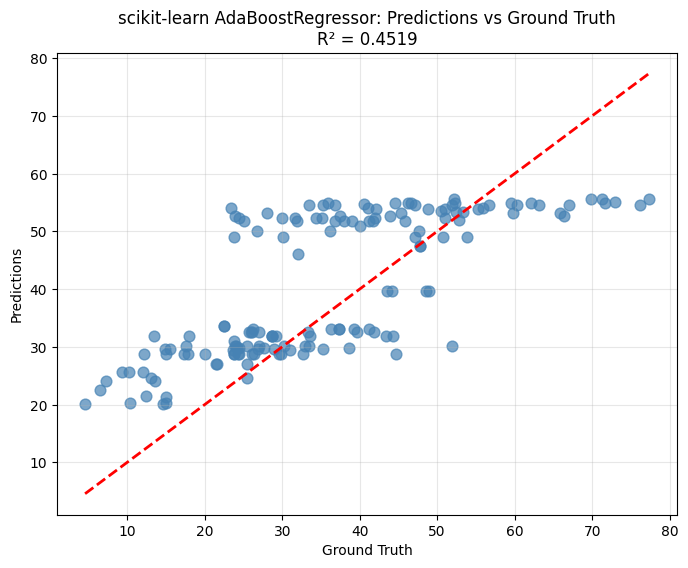

In [20]:
# Use the model trained in Task 5
# Make predictions on the test data using the trained sklearn model
y_testPredSklearn = sklearn_adaboost.predict(X_test)

# Calculate the R-squared score to measure how well our predictions match the actual values
r2_sklearn = r2_score(y_test, y_testPredSklearn)

# Print the R-squared score with 4 decimal places
print(f"Test Set R² Score: {r2_sklearn:.4f}")

# Create scatter plot

# Create a new figure with width 8 and height 6 inches
plt.figure(figsize=(8, 6))

# Plot actual values vs predicted values as blue dots with some transparency
plt.scatter(y_test, y_testPredSklearn, alpha=0.7, s=60, color='steelblue')

# Draw a red dashed diagonal line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Set the label for the x-axis
plt.xlabel('Ground Truth')

# Set the label for the y-axis
plt.ylabel('Predictions')

# Set the title of the plot with the R-squared score
plt.title(f'scikit-learn AdaBoostRegressor: Predictions vs Ground Truth\nR² = {r2_sklearn:.4f}')

# Add a grid to the plot with some transparency
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

7. Compare the from scratch-implementation of Adaboost Regressor to that of scikit-learn.  



In [21]:
# Use results from Tasks 4 and 6

# Print the header for the performance comparison table
print("Performance Comparison:")

# Print the column headers with proper spacing alignment
print(f"{'Metric':<15} {'Custom':<15} {'Scikit-learn':<15} {'Difference':<15}")

# Print the R² score comparison with formatted output
print(f"{'R² Score':<15} {r2_custom:<15.4f} {r2_sklearn:<15.4f} {r2_custom-r2_sklearn:<15.4f}")

# Calculate additional metrics for comparison

# Calculate Root Mean Square Error for custom implementation
rmseCustom = np.sqrt(mean_squared_error(y_test, y_testPredCustom))

# Calculate Root Mean Square Error for scikit-learn implementation
rmseSklearn = np.sqrt(mean_squared_error(y_test, y_testPredSklearn))

# Calculate Mean Absolute Error for custom implementation
maeCustom = mean_absolute_error(y_test, y_testPredCustom)

# Calculate Mean Absolute Error for scikit-learn implementation
maeSklearn = mean_absolute_error(y_test, y_testPredSklearn)

# Print the RMSE comparison with formatted output
print(f"{'RMSE':<15} {rmseCustom:<15.4f} {rmseSklearn:<15.4f} {rmseCustom-rmseSklearn:<15.4f}")

# Print the MAE comparison with formatted output
print(f"{'MAE':<15} {maeCustom:<15.4f} {maeSklearn:<15.4f} {maeCustom-maeSklearn:<15.4f}")

# Print a newline and observation header
print("\nObservation:")

# Check if custom implementation performed better
if r2_custom > r2_sklearn:
    # Print message when custom model outperformed scikit-learn
    print("Custom AdaBoost.R2 slightly outperformed scikit-learn's model, possibly due to different error normalization or weighting scheme.")
else:
    # Print message when scikit-learn model performed better
    print("scikit-learn's AdaBoostRegressor performed slightly better, likely due to optimized internal handling and numerical stability.")


Performance Comparison:
Metric          Custom          Scikit-learn    Difference     
R² Score        0.4638          0.4519          0.0119         
RMSE            11.6047         11.7327         -0.1280        
MAE             9.8088          9.4468          0.3621         

Observation:
Custom AdaBoost.R2 slightly outperformed scikit-learn's model, possibly due to different error normalization or weighting scheme.
